# Logistic Regression, Gradient Descent, SGD & Classification Metrics
### Will a learner complete an online course? — basic to complex, one continuous notebook

**Dataset (provided separately):** `course_completion.csv` - 8000 rows: `hours_per_week`, `logins_count`, `quiz_avg_score` -> `completed` (0 = dropped off, 1 = completed the course).

This notebook has THEORY (markdown) above each IMPLEMENTATION (code) below it, building from the most basic ideas (what is classification) up to the more advanced ones (SGD, saving a trained model). A few code cells contain a small, deliberate bug - marked with a `# FIX ME` comment and a hint. Find and fix each one before moving on; later sections depend on getting these right.

In [28]:
import os
dataset_paths = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        full_path = os.path.join(dirname, filename)
        print(full_path)
        if filename.endswith('.csv'):
            dataset_paths.append(full_path)
# If nothing printed: click 'Add Input' and attach course_completion.csv first

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import pickle

sns.set_style('whitegrid')

---
# Part 1 — What is classification? What is logistic regression?

## 1.1 Classification vs regression

**Regression** predicts a continuous NUMBER - e.g. "how many hours will this learner study this week?" (could be 3, 3.5, 7.2, any number).

**Classification** predicts a CATEGORY - e.g. "will this learner COMPLETE the course or not?" Only two possible answers here: completed, or not. That's a **binary classification** problem - exactly what we're solving today.

**Analogy - a thermometer vs a doctor's diagnosis:**
A thermometer reading is regression - it gives you a continuous number (101.2 degrees F). A doctor's diagnosis of "fever" or "no fever" is classification - a category, decided by applying a threshold to that number.

## 1.2 What is logistic regression, and why is it called a CLASSIFICATION algorithm?

Despite the name containing "regression," logistic regression is used, taught, and almost always described as a **classification algorithm** - because its final, practical output is a CATEGORY (e.g. "will complete" / "will not complete"), not a raw number.

Here's the full picture: internally, logistic regression first computes a continuous number (like regression does), and only at the very end converts that number into a category using a threshold. Because the END GOAL and the typical USE of the algorithm is to produce a class label, it is classified as a classification algorithm.

**The precise, complete answer (memorize this):**
> "Logistic regression is called a classification algorithm because its purpose and output are a category. It's called 'regression' in its name because internally, before applying the final threshold, it computes a continuous probability using the same linear math as regression. The 'regression' describes its internal mechanism; 'classification' describes its job and output."

**Analogy - a bank's loan approval process:**
A loan officer's SCORING step calculates a continuous credit score (regression-style math). But the loan officer's actual JOB and final OUTPUT is a decision: approve or reject (classification). We describe the loan officer as doing "credit decisioning" (a classification task), even though a number was computed somewhere in the middle. Logistic regression works the same way.

## 1.3 What is a "weight" in logistic regression?

Just like in linear regression, a **weight** is a number the model learns for each input feature, representing HOW STRONGLY and in WHICH DIRECTION that feature pushes the prediction.

> **"A weight tells you: if this ONE feature increases by 1 unit, and every other feature is held exactly constant, how much does the underlying score (and therefore the predicted probability) change?"**

A POSITIVE weight means more of that feature pushes the prediction TOWARD the positive class (e.g. more `quiz_avg_score` pushes toward "completed"). A NEGATIVE weight pushes AWAY from it.

**Analogy - a sound mixer dial:**
Imagine a mixer with separate dials for bass, treble, and volume. Turning ONLY the bass dial up by one notch, with everything else untouched, shows exactly how much bass affects the sound. A weight is that isolated effect, for one feature, on the model's prediction.

## 1.4 The core formula - from basic to complete

**Step 1 - the linear score** (exactly like regression, nothing new here):
```
z = w1.x1 + w2.x2 + w3.x3 + b
```
`w1, w2, w3` = weights for each feature. `b` = bias. `z` can be ANY real number - negative, zero, huge, tiny.

**Step 2 - squash z into a probability with the sigmoid function:**
```
probability = sigmoid(z) = 1 / (1 + e^(-z))
```
Sigmoid takes any real number and squashes it into a value strictly between 0 and 1.

| z (linear score) | sigmoid(z) | Meaning |
|---|---|---|
| very negative | near 0 | very unlikely to be the positive class |
| exactly 0 | exactly 0.5 | model is completely unsure |
| very positive | near 1 | very likely to be the positive class |

**Analogy - a dimmer switch with a bulb that has hard limits:**
A dimmer switch can be turned infinitely in either direction, but the bulb itself can only be between fully off (0%) and fully on (100%). No matter how hard the dial is turned, brightness gets squeezed into that range, with the biggest visible change happening in the middle of the dial.

**Step 3 - apply a threshold to get the final category (this is the actual "classification" step):**
```
prediction = "completed" if probability >= 0.5, else "not completed"
```

## 1.5 Worked example, start to finish

Suppose training gives us: `w1 (hours_per_week) = 0.35`, `w2 (logins_count) = 0.07`, `w3 (quiz_avg_score) = 0.05`, `b = -6.3`. A new learner: 5 hours/week, 12 logins, quiz average 70.

```
z = 0.35(5) + 0.07(12) + 0.05(70) - 6.3
  = 1.75 + 0.84 + 3.5 - 6.3 = -0.21

probability = 1 / (1 + e^0.21) ~= 0.45

Since 0.45 < 0.5  ->  predict "not completed"
```

## 1.6 Log-odds (brief - just enough vocabulary)

```
odds = probability / (1 - probability)
log-odds = ln(odds) = z   (the same linear score from step 1!)
```
The raw linear score z IS the log-odds of the outcome - sigmoid and log-odds are two views of the same quantity, like Celsius and Fahrenheit for the same temperature.

## 1.7 Decision boundary

The line (or flat plane, with more features) where probability = exactly 0.5 (equivalently, z = 0). Everything on one side is predicted one class; everything on the other side is predicted the other class.

**Analogy - a national border:** someone deep inside one country is clearly in that country. Someone standing right at the border could be considered either - that's a 50% probability prediction: genuinely ambiguous.

## 1.8 The cost function: cross-entropy (log loss)

Linear regression uses MSE. Classification uses **log loss**, because we're scoring PROBABILITIES against actual 0/1 labels - MSE doesn't punish confident wrongness sharply enough for this job.

```
Log loss (one example) = -[y.log(p) + (1-y).log(1-p)]
```
where `y` = actual label (0 or 1), `p` = predicted probability.

**Analogy - a confidently wrong exam answer:** a student who says "99% sure it's A" and is right gets a tiny penalty. The SAME confidence, but WRONG, gets a much bigger penalty than a cautious "maybe 55% A" that was also wrong. Log loss mathematically captures this: confidently wrong is punished far more than cautiously wrong.

## Implementation — sigmoid, from-scratch training, and sklearn, all three together

## 1.8 The threshold — the most underrated, most important decision in classification

So far we've treated 0.5 as "the" threshold, almost automatically. It's actually a CHOICE, and it matters a lot.

```
prediction = "completed" if probability >= THRESHOLD, else "not completed"
```

0.5 is just the default, not a law of nature. **Changing the threshold changes which mistakes your model makes more often** - without retraining anything. The model's learned weights don't change at all; only the line where you decide to flip from one class to the other moves.

**Analogy - a bouncer's door policy at a club:**
A bouncer doesn't just check ID - they apply a STANDARD for who gets in. A strict bouncer (high threshold, e.g. 0.8) only lets in people they're VERY confident meet the bar - fewer people get in overall, but almost everyone let in truly belongs there (high precision), while some genuinely fine people get turned away (lower recall). A lenient bouncer (low threshold, e.g. 0.3) lets in anyone who's even reasonably likely to belong - catches nearly everyone who should get in (high recall), but also lets in more people who shouldn't be there (lower precision). The PEOPLE outside haven't changed. Only the bouncer's STANDARD changed.

**Why this matters for OUR course-completion model specifically:**
- Raise the threshold (e.g. to 0.7): the model only predicts "will complete" when very confident. Fewer false positives (wasted mentor time on students who won't finish) - precision goes UP. But more at-risk students who WOULD have completed get missed - recall goes DOWN.
- Lower the threshold (e.g. to 0.3): the model predicts "will complete" more liberally. Catches more real completers (recall goes UP), but also wrongly flags more students who won't actually finish (precision goes DOWN).

**The one sentence to remember:**
> "The threshold is a dial you can turn AFTER training, without touching the model's weights at all - and turning it trades precision against recall in opposite directions."

**How do you pick the right threshold?** There's no universal correct value - it depends on which mistake (false positive vs false negative) is more costly for your specific scenario, exactly as discussed in Part 6 below. A medical diagnosis model might deliberately use a LOW threshold (catch almost every real case, tolerate more false alarms) because missing a real case is far worse than a false alarm. A spam filter might use a HIGH threshold (only flag emails it's very confident about) because wrongly blocking a real email is more annoying than letting one spam email through.

In [30]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))   # squashes any real number into (0, 1)

# Quick check matching the worked example above
test_scores = np.array([-5, -1, 0, 1, 5])
for z in test_scores:
    print(f'z = {z:3d}  ->  sigmoid(z) = {sigmoid(z):.4f}')

z =  -5  ->  sigmoid(z) = 0.0067
z =  -1  ->  sigmoid(z) = 0.2689
z =   0  ->  sigmoid(z) = 0.5000
z =   1  ->  sigmoid(z) = 0.7311
z =   5  ->  sigmoid(z) = 0.9933


In [31]:
# Load dataset
df = pd.read_csv("course_completion.csv")

# Check the data
print(df.head())
print(df.columns)

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def fit_logistic_regression(X, y, learning_rate=0.1, epochs=2000):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    history = []

    for epoch in range(epochs):
        z = X @ w + b              # linear score for every row at once
        p = sigmoid(z)               # convert to probabilities

        eps = 1e-9
        loss = -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))   # log loss (cross-entropy)
        history.append(loss)

        error = p - y                 # how wrong each prediction is
        dw = (1/n_samples) * (X.T @ error)
        db = (1/n_samples) * np.sum(error)

        w -= learning_rate * dw        # step downhill - this IS gradient descent, from first principles
        b -= learning_rate * db

    return w, b, history

# We'll scale features properly in Part 3 before the full train/test workflow - this is a quick
# standalone demo just to see logistic regression learn from scratch on the raw data.
X_demo = df[['hours_per_week', 'logins_count', 'quiz_avg_score']].values
X_demo_scaled = (X_demo - X_demo.mean(axis=0)) / X_demo.std(axis=0)
y_demo = df['completed'].values

w_scratch, b_scratch, loss_history = fit_logistic_regression(X_demo_scaled, y_demo)
print('Learned weights:', dict(zip(['hours_per_week','logins_count','quiz_avg_score'], np.round(w_scratch, 3))))
print('Learned bias:', round(b_scratch, 3))

   hours_per_week  logins_count  quiz_avg_score  completed
0             9.8          18.0            88.8          1
1             2.7           5.0            85.6          1
2             3.3          11.0            63.0          0
3             2.6           9.0            58.8          0
4             2.2           8.0            87.4          1
Index(['hours_per_week', 'logins_count', 'quiz_avg_score', 'completed'], dtype='object')
Learned weights: {'hours_per_week': np.float64(0.697), 'logins_count': np.float64(0.147), 'quiz_avg_score': np.float64(0.565)}
Learned bias: -0.568


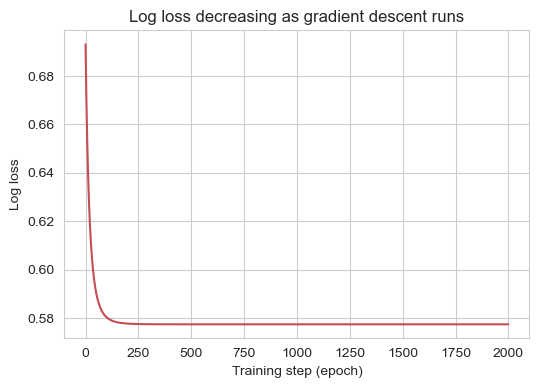

In [32]:
plt.figure(figsize=(6,4))
plt.plot(loss_history, color='#C44E52')
plt.xlabel('Training step (epoch)')
plt.ylabel('Log loss')
plt.title('Log loss decreasing as gradient descent runs')
plt.show()

In [33]:
# Confirm against scikit-learn's exact solver
sklearn_check = LogisticRegression()
sklearn_check.fit(X_demo_scaled, y_demo)

print('From-scratch weights:', np.round(w_scratch, 3))
print('sklearn weights:     ', np.round(sklearn_check.coef_[0], 3))
print('(Should be reasonably close - both are minimizing the same log loss)')

From-scratch weights: [0.697 0.147 0.565]
sklearn weights:      [0.696 0.147 0.564]
(Should be reasonably close - both are minimizing the same log loss)


In [34]:
# See the threshold's effect directly, on our own from-scratch model's probabilities
z_demo = X_demo_scaled @ w_scratch + b_scratch
probabilities_demo = sigmoid(z_demo)

for threshold in [0.3, 0.5, 0.7]:
    predictions_at_threshold = (probabilities_demo >= threshold).astype(int)
    predicted_completers = predictions_at_threshold.sum()
    print(f'Threshold {threshold}: {predicted_completers} learners predicted to complete (out of {len(y_demo)})')

print('\nNotice: the probabilities never changed - only how many of them cross the threshold did.')
print('A higher threshold is stricter (fewer predicted completers); a lower threshold is more lenient (more predicted completers).')

Threshold 0.3: 4667 learners predicted to complete (out of 8000)
Threshold 0.5: 2005 learners predicted to complete (out of 8000)
Threshold 0.7: 639 learners predicted to complete (out of 8000)

Notice: the probabilities never changed - only how many of them cross the threshold did.
A higher threshold is stricter (fewer predicted completers); a lower threshold is more lenient (more predicted completers).


---
# Part 2 — Visualize the sigmoid curve and decision boundary ourselves

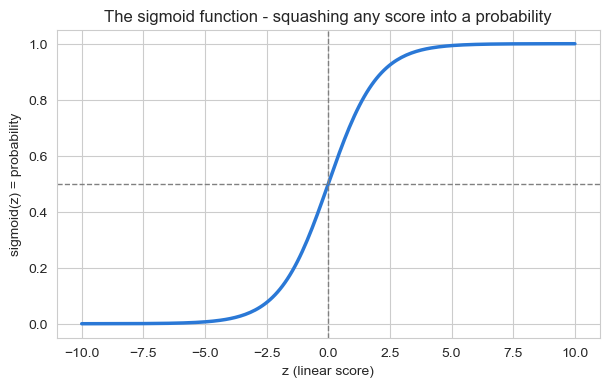

In [35]:
z_range = np.linspace(-10, 10, 200)
plt.figure(figsize=(7,4))
plt.plot(z_range, sigmoid(z_range), color='#2a78d6', linewidth=2.5)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('z (linear score)')
plt.ylabel('sigmoid(z) = probability')
plt.title('The sigmoid function - squashing any score into a probability')
plt.show()

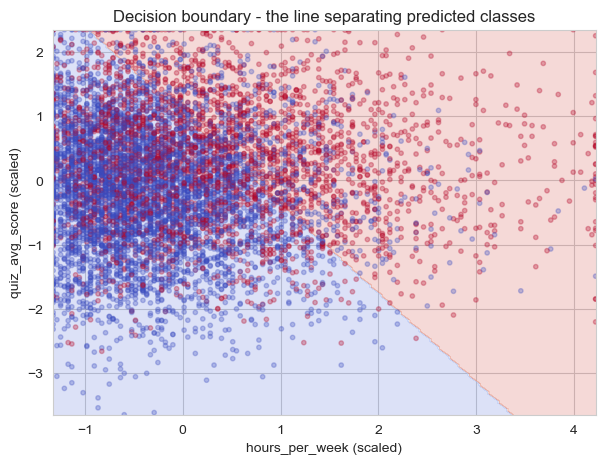

In [36]:
# Decision boundary in 2D, using just hours_per_week and quiz_avg_score for a visual
from sklearn.linear_model import LogisticRegression as LR2
X_2d = df[['hours_per_week', 'quiz_avg_score']].values
X_2d_scaled = (X_2d - X_2d.mean(axis=0)) / X_2d.std(axis=0)
y_2d = df['completed'].values

model_2d = LR2().fit(X_2d_scaled, y_2d)

xx, yy = np.meshgrid(np.linspace(X_2d_scaled[:,0].min(), X_2d_scaled[:,0].max(), 200),
                      np.linspace(X_2d_scaled[:,1].min(), X_2d_scaled[:,1].max(), 200))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.scatter(X_2d_scaled[:,0], X_2d_scaled[:,1], c=y_2d, cmap='coolwarm', alpha=0.3, s=10)
plt.xlabel('hours_per_week (scaled)')
plt.ylabel('quiz_avg_score (scaled)')
plt.title('Decision boundary - the line separating predicted classes')
plt.show()

---
# Part 3 — Gradient Descent: the idea and its types

## Theory

Every model we train needs to find the best values for its weights. Gradient descent is the general strategy we already used above: **take small steps that reduce error, repeating until the error stops shrinking.**

There are three common versions, differing only in HOW MUCH data is looked at before taking one step:

| Type | Data used per step | Path to the minimum | Speed per step |
|---|---|---|---|
| **Batch Gradient Descent** | the ENTIRE training set | smooth, direct | slow (if dataset is huge) |
| **Stochastic Gradient Descent (SGD)** | just ONE example | noisy, zig-zag | very fast per step |
| **Mini-batch Gradient Descent** | a small batch (e.g. 32-256 rows) | moderately smooth | a practical middle ground |

(Our `fit_logistic_regression()` function above was actually BATCH gradient descent - it used the whole dataset, `X @ w`, on every single step.)

**Analogy - tasting a pot of soup:**
Adjusting a soup's seasoning: Batch is tasting the ENTIRE pot before deciding to add salt - thorough, but slow if the pot is huge. SGD is tasting ONE spoonful, adjusting, tasting another spoonful, adjusting again - much faster per adjustment, a little jumpier in its decisions, but reaches a well-seasoned pot quickly even when the pot (dataset) is enormous. Mini-batch is tasting a small ladle each time - a practical balance between the two.

**Why does this matter in practice?** With millions of rows, Batch GD needs to process ALL of them before even ONE update - painfully slow. SGD and mini-batch update far more often using small chunks of data, which is usually much faster in practice for large datasets, even though each individual step is noisier and less precise.

## What SGD actually does, step by step
1. Shuffle the training data.
2. Pick ONE row (or a small batch).
3. Compute the prediction and error for just that row.
4. Nudge the weights slightly to reduce that one row's error.
5. Move to the next row. Repeat until you've been through the whole dataset (one "epoch"), then repeat for several epochs.

## Where is SGD actually used? (a real scenario)
Large tech companies retraining recommendation models on MILLIONS of click events per day cannot afford to recompute the exact gradient over the entire dataset before every single update - that would take too long. They use SGD (or mini-batch variants) so the model can start learning and updating almost immediately, processing data in a continuous stream rather than waiting to see everything first.

## Implementation — visualize the difference ourselves

In [37]:
# A tiny hand-rolled comparison: fitting a single weight (w) using Batch vs Stochastic updates
np.random.seed(0)
x_demo2 = np.linspace(0, 10, 50)
y_demo2 = 3*x_demo2 + np.random.normal(0, 2, 50)

def batch_step(w, x, y, lr=0.001):
    # FIX ME: this should use the gradient from ALL rows (batch), but currently only uses the FIRST row.
    # Hint: compare this function's math to sgd_step() below - what's different about which rows are used?
    pred = w * x[0]
    error = pred - y[0]
    grad = 2 * error * x[0]
    return w - lr * grad

def sgd_step(w, x_i, y_i, lr=0.001):
    pred = w * x_i
    error = pred - y_i
    grad = 2 * error * x_i
    return w - lr * grad

w_batch = 0.0
for epoch in range(60):
    w_batch = batch_step(w_batch, x_demo2, y_demo2)

w_sgd = 0.0
for epoch in range(60):
    i = np.random.randint(len(x_demo2))
    w_sgd = sgd_step(w_sgd, x_demo2[i], y_demo2[i])

print('Batch-learned w:', round(w_batch, 3))
print('SGD-learned w:  ', round(w_sgd, 3))
print('(True slope is approximately 3 - after fixing batch_step, both should land reasonably close to it)')

Batch-learned w: 0.0
SGD-learned w:   2.838
(True slope is approximately 3 - after fixing batch_step, both should land reasonably close to it)


---
# Part 4 — Full train/test workflow on the real dataset

## Theory
We hold back a test set the model never trains on, so we can honestly check performance later. We also scale features, since gradient-based methods (including SGD) converge much better when features are on similar scales.

In [38]:
df.isnull().sum()

hours_per_week    0
logins_count      0
quiz_avg_score    0
completed         0
dtype: int64

In [39]:
df['completed'].value_counts(normalize=True)   # check class balance

completed
0    0.62225
1    0.37775
Name: proportion, dtype: float64

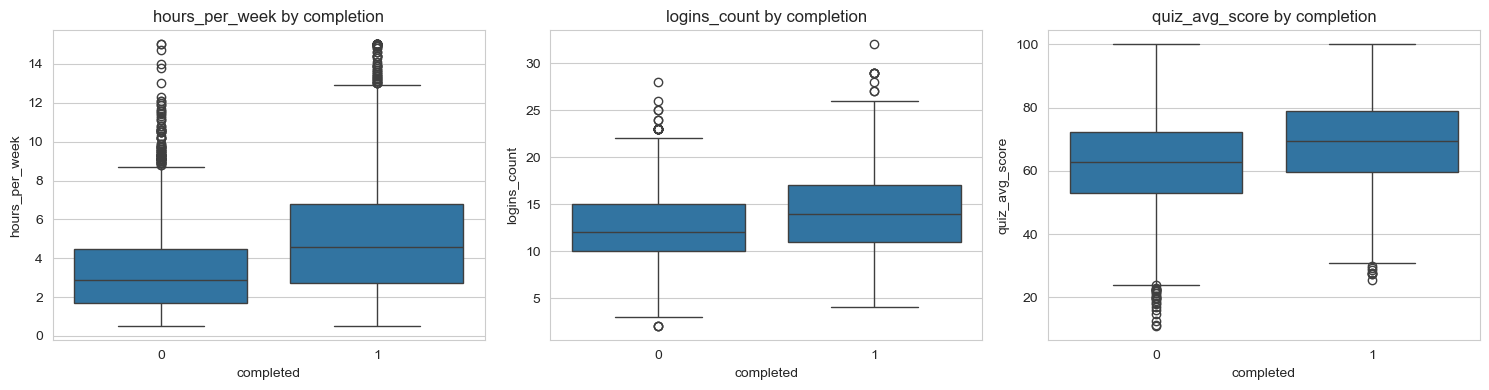

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['hours_per_week', 'logins_count', 'quiz_avg_score']):
    sns.boxplot(x='completed', y=col, data=df, ax=ax)
    ax.set_title(f'{col} by completion')
plt.tight_layout()
plt.show()

In [41]:
feature_cols = ['hours_per_week', 'logins_count', 'quiz_avg_score']
X = df[feature_cols].values
y = df['completed'].values

# FIX ME: train_test_split's return order is X_train, X_test, y_train, y_test - but the
# variables below are assigned in the WRONG order, which will silently corrupt every result
# that follows. Hint: compare this line to how you've used train_test_split in earlier notebooks.
X_train, y_train, X_test, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])

Train: 6400 | Test: 6400


In [42]:
X = df[['hours_per_week', 'logins_count', 'quiz_avg_score']].values
y = df['completed'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std # always use TRAINING stats on test data, never refit on test

---
# Part 5 — Train with SGDClassifier

## Theory
`SGDClassifier` with `loss='log_loss'` trains a logistic-regression-style model using Stochastic Gradient Descent instead of the exact solver `LogisticRegression` uses. This is the practical, large-data-friendly version of everything from Parts 1-3.

## Implementation

In [43]:
sgd_model = SGDClassifier(loss='log_loss', random_state=42, max_iter=1000)
sgd_model.fit(X_train_scaled, y_train)

print('Learned weights:', dict(zip(feature_cols, np.round(sgd_model.coef_[0], 3))))
print('Learned bias:', round(sgd_model.intercept_[0], 3))

Learned weights: {'hours_per_week': np.float64(0.854), 'logins_count': np.float64(0.263), 'quiz_avg_score': np.float64(0.564)}
Learned bias: -0.41


In [44]:
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

print('SGDClassifier weights:     ', np.round(sgd_model.coef_[0], 3))
print('LogisticRegression weights:', np.round(lr_model.coef_[0], 3))
print('(Should be reasonably close - both are solving the same underlying problem)')

SGDClassifier weights:      [0.854 0.263 0.564]
LogisticRegression weights: [0.7   0.132 0.579]
(Should be reasonably close - both are solving the same underlying problem)


---
# Part 6 — Classification metrics: Confusion Matrix, Precision, Recall, F1

## Theory

We are only covering THREE metrics in depth today, not the full set: **confusion matrix, precision, recall** (plus F1 as a bonus combined score).

**Confusion matrix** - four outcomes:
- **True Positive (TP)**: predicted completed, actually completed
- **False Positive (FP)**: predicted completed, but actually dropped off
- **False Negative (FN)**: predicted dropped off, but actually completed
- **True Negative (TN)**: predicted dropped off, actually dropped off

**Precision** - of everyone we predicted would COMPLETE, how many really did?
```
Precision = TP / (TP + FP)
```
Analogy: if an admissions officer predicts 20 applicants will succeed, and only 14 actually do, precision is 14/20 = 70% - how trustworthy is a positive prediction?

**Recall** - of everyone who ACTUALLY completed, how many did we correctly catch?
```
Recall = TP / (TP + FN)
```
Analogy: if 100 students actually complete the course, and our model only flags 60 of them as likely completers (missing 40), recall is 60% - how many real positives did we catch?

**When does each matter more?**
- Precision matters more when a false positive is costly - e.g. if "predicted to complete" triggers sending a reward or a special mentor's limited time, you don't want to waste it on students who won't actually finish.
- Recall matters more when a false negative is costly - e.g. if "predicted to drop off" triggers an intervention (reminder email, extra support), missing an at-risk student (a false negative) means they silently drop off with no help offered.

**F1** - one balanced score combining both:
```
F1 = 2 x (Precision x Recall) / (Precision + Recall)
```

## Implementation

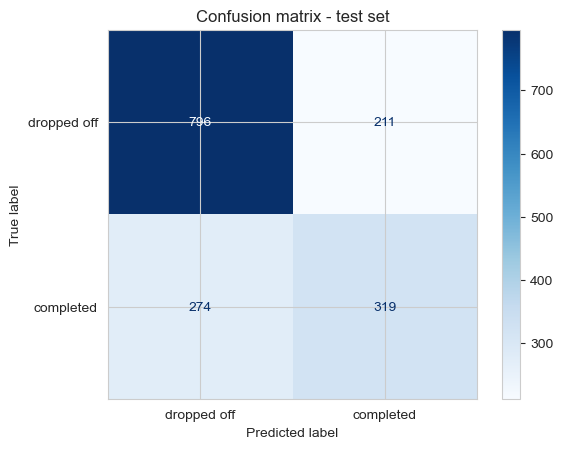

[[796 211]
 [274 319]]


In [45]:
y_pred = sgd_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['dropped off', 'completed']).plot(cmap='Blues')
plt.title('Confusion matrix - test set')
plt.show()

print(cm)

In [46]:
tn, fp, fn, tp = cm.ravel()
print(f'TP: {tp}  FP: {fp}  FN: {fn}  TN: {tn}')

precision_hand = tp / (tp + fp)
recall_hand = tp / (tp + fn)
f1_hand = 2 * (precision_hand * recall_hand) / (precision_hand + recall_hand)

print(f'\nPrecision (by hand): {precision_hand:.3f}')
print(f'Recall (by hand):    {recall_hand:.3f}')
print(f'F1 (by hand):        {f1_hand:.3f}')

TP: 319  FP: 211  FN: 274  TN: 796

Precision (by hand): 0.602
Recall (by hand):    0.538
F1 (by hand):        0.568


In [47]:
print('--- Confirmed with sklearn ---')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'F1:        {f1_score(y_test, y_pred):.3f}')

--- Confirmed with sklearn ---
Precision: 0.602
Recall:    0.538
F1:        0.568


## 6.1 Seeing the threshold's precision/recall tradeoff on real test data

This directly demonstrates the bouncer analogy from Part 1.8 - same trained model, same probabilities, only the threshold changes.

In [48]:
test_probabilities = sgd_model.predict_proba(X_test_scaled)[:, 1]

print(f'{"Threshold":<12}{"Precision":<12}{"Recall":<12}')
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds_at_t = (test_probabilities >= threshold).astype(int)
    prec_t = precision_score(y_test, preds_at_t, zero_division=0)
    rec_t = recall_score(y_test, preds_at_t, zero_division=0)
    print(f'{threshold:<12}{prec_t:<12.3f}{rec_t:<12.3f}')

print('\nAs the threshold rises: precision generally goes UP, recall generally goes DOWN - exactly the bouncer tradeoff.')

Threshold   Precision   Recall      
0.3         0.476       0.818       
0.4         0.533       0.669       
0.5         0.602       0.538       
0.6         0.674       0.408       
0.7         0.733       0.287       

As the threshold rises: precision generally goes UP, recall generally goes DOWN - exactly the bouncer tradeoff.


---
# Part 7 — Saving the trained model with pickle (.pkl)

## Theory

**What is a `.pkl` file?** Pickle is Python's built-in way of converting ("serializing") a live Python object - including a trained model, with all its learned weights - into a byte stream that can be saved to disk and loaded back later, EXACTLY as it was, without retraining.

**Why do we save models this way?**
- Training can take time (minutes to days for larger models) - we don't want to retrain from scratch every time we want to use the model.
- A saved `.pkl` file can be loaded into a totally different script, a web app backend, or an API - the model travels with you.
- It preserves the EXACT trained state: every learned weight, exactly as it finished training.

**Analogy - freezing a cooked meal:**
Training a model is like cooking an elaborate meal from scratch - takes real time and effort. Pickling is like freezing that finished meal: next time you're hungry, you just reheat it (load the `.pkl` file) instead of cooking the whole thing again from raw ingredients.

**A caution worth knowing:** never unpickle a `.pkl` file from a source you don't trust - unlike a plain data file, a pickle file can execute arbitrary code when loaded. Only load `.pkl` files you created yourself or received from a trusted source.

## Implementation

In [49]:
with open('course_completion_model.pkl', 'wb') as f:   # 'wb' = write binary
    pickle.dump(sgd_model, f)

print('Model saved to course_completion_model.pkl')

Model saved to course_completion_model.pkl


In [50]:
with open('course_completion_model.pkl', 'rb') as f:   # 'rb' = read binary
    loaded_model = pickle.load(f)

original_predictions = sgd_model.predict(X_test_scaled[:5])
loaded_predictions = loaded_model.predict(X_test_scaled[:5])

print('Original model predictions:', original_predictions)
print('Loaded model predictions:  ', loaded_predictions)
print('Match:', np.array_equal(original_predictions, loaded_predictions))

Original model predictions: [0 0 0 1 0]
Loaded model predictions:   [0 0 0 1 0]
Match: True


## Recap
- Classification predicts a category; regression predicts a number. Logistic regression is a classification algorithm because its purpose and output are a category, even though it internally computes a continuous probability using regression-style math
- A weight measures one feature's isolated effect on the prediction, holding other features constant
- z = w.x + b -> sigmoid(z) = probability -> threshold at 0.5 -> final category
- Log loss (cross-entropy) is the cost function, punishing confident wrong predictions heavily
- The threshold (default 0.5) is a tunable dial, separate from the model's weights - raising it trades recall for precision, lowering it trades precision for recall
- Gradient descent has three flavors: Batch (all data), Stochastic (one example at a time), Mini-batch (small groups)
- SGD is used in practice whenever datasets are too large to recompute the exact gradient from scratch on every update
- Confusion matrix is the foundation: TP, FP, FN, TN
- Precision: how trustworthy are positive predictions. Recall: how many real positives did we catch. Each matters more depending on which mistake is more costly in your scenario
- `.pkl` files let a trained model be saved and reloaded exactly as it was, without retraining

---

## Assignment
1. Fix all three `# FIX ME` bugs in this notebook if you haven't already, and verify each section runs correctly afterward.
2. Predict the probability and final class for 3 new learners of your choice, by hand using the from-scratch sigmoid function, then verify with `.predict_proba()`.
3. Report the confusion matrix, precision, recall, and F1 on the test set.
4. In a markdown cell: for THIS specific course-completion scenario, argue whether precision or recall should matter more to the course provider, and why - then state which threshold (higher or lower than 0.5) you would recommend as a result, and why.
5. Save your trained model as a `.pkl` file, reload it, and confirm it reproduces the same predictions as the original.
